<a href="https://colab.research.google.com/github/gapalfaro-cmyk/gapalfaro-cmyk-Proyecto-de-fin-de-modulo-7.3---Alfaro-Badillo-Cruz-Perez-Rupit-/blob/main/Tarea%203.2_Alfaro_Badillo_Cruz_Perez_Rupit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividades para hoy

1. Para el entorno estacionario y para el entorno no-estacionario probar con diferentes valores de $\epsilon$ y describir cómo afecta el algoritmo.

2. Para el entorno estacionario usar tasa de aprendizaje constante y describir lo observado con el desempeño del algoritmo.

3. Para el entorno no estacionario utilizar como tasa de aprendizaje $1/N(a)$ y describir lo observado con el desempeño del algoritmo.

1. Para el entorno estacionario y para el entorno no-estacionario probar con diferentes valores de  ϵ  y describir cómo afecta el algoritmo.

# Aprendizaje por refuerzo
## Entorno estacionario

valor de epsilon = 0.0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)

# Estimación inicial de recompensa
Q = np.zeros(n_actions)

# Número de veces que cada acción ha sido seleccionada
N = np.zeros(n_actions)

#cuánto explora el algortimo
eplison = 0.0
T = 1000

rewards = []
actions = []

for t in range(T):

    # Exploration
    if np.random.rand() < eplison:
        action = np.random.randint(n_actions)

    # Exploitation
    else:
        action = np.argmax(Q)

    # Respuesta del usuario
    reward = np.random.rand() < true_prob[action]

    # Guardamos resultados
    rewards.append(reward)
    actions.append(action)

    # Actualizamos la estimación
    N[action] += 1
    #promedio acumulado de las recompensas
    Q[action] += (reward - Q[action]) / N[action]


In [ ]:
for i in range(n_actions):
    print(
        content[i],
        " | valor real:", true_prob[i],
        " | valor aprendido:", round(Q[i], 3),
        " | veces mostrado:", int(N[i])
    )

Deportes  | valor real: 0.2  | valor aprendido: 0.194  | veces mostrado: 1000
Noticias  | valor real: 0.6  | valor aprendido: 0.0  | veces mostrado: 0
Tecnología  | valor real: 0.8  | valor aprendido: 0.0  | veces mostrado: 0
Entretenimiento  | valor real: 0.4  | valor aprendido: 0.0  | veces mostrado: 0


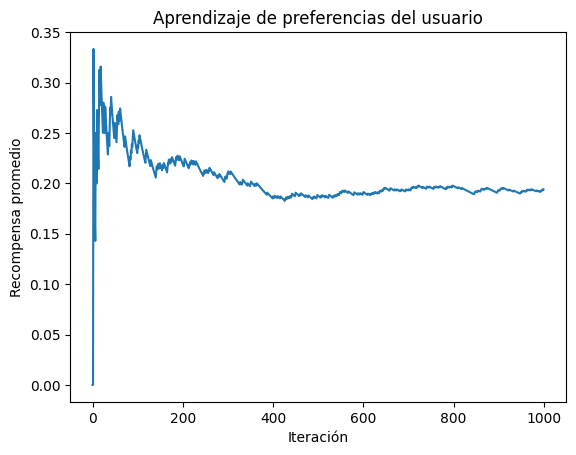

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Aprendizaje de preferencias del usuario")
plt.show()

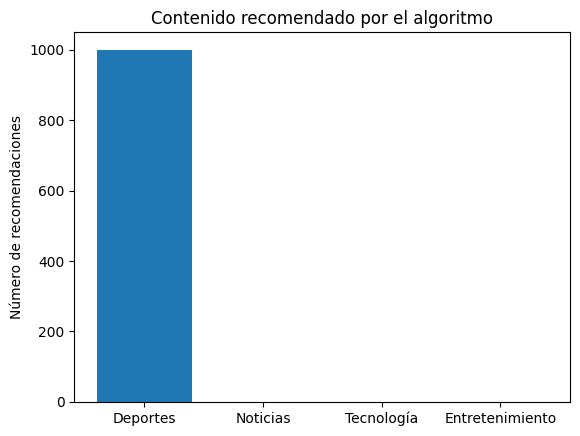

In [ ]:
counts = [actions.count(i) for i in range(n_actions)]

plt.bar(content, counts)
plt.ylabel("Número de recomendaciones")
plt.title("Contenido recomendado por el algoritmo")
plt.show()

El algoritmo seleccionó Deportes durante las 1000 iteraciones porque inicialmente todas las estimaciones Q eran iguales a cero y argmax seleccionó la primera opción. Al no explorar las demás opciones, nunca descubrió que Tecnología tenía la mayor probabilidad de recompensa. desempeño bajo

## Entorno estacionario
epsilon = 0.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)

# Estimación inicial de recompensa
Q = np.zeros(n_actions)

# Número de veces que cada acción ha sido seleccionada
N = np.zeros(n_actions)

epsilon = 0.1
T = 1000

rewards = []
actions = []

for t in range(T):

    # Exploration
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)

    # Exploitation
    else:
        action = np.argmax(Q)

    # Respuesta del usuario
    reward = np.random.rand() < true_prob[action]

    # Guardamos resultados
    rewards.append(reward)
    actions.append(action)

    # Actualizamos la estimación
    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]

In [ ]:
for i in range(n_actions):
    print(
        content[i],
        " | valor real:", true_prob[i],
        " | valor aprendido:", round(Q[i], 3),
        " | veces mostrado:", int(N[i])
    )

Deportes  | valor real: 0.2  | valor aprendido: 0.2  | veces mostrado: 30
Noticias  | valor real: 0.6  | valor aprendido: 0.5  | veces mostrado: 30
Tecnología  | valor real: 0.8  | valor aprendido: 0.806  | veces mostrado: 907
Entretenimiento  | valor real: 0.4  | valor aprendido: 0.424  | veces mostrado: 33


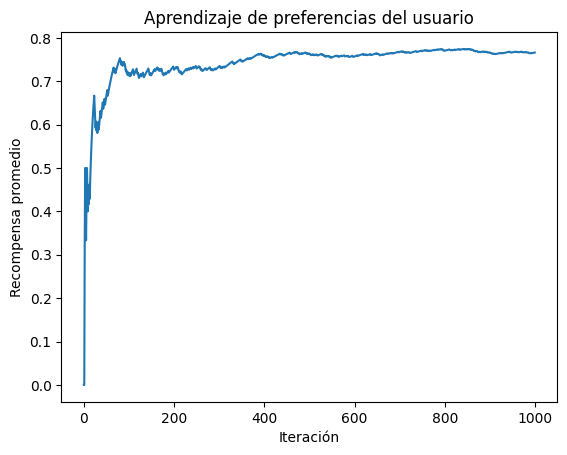

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Aprendizaje de preferencias del usuario")
plt.show()

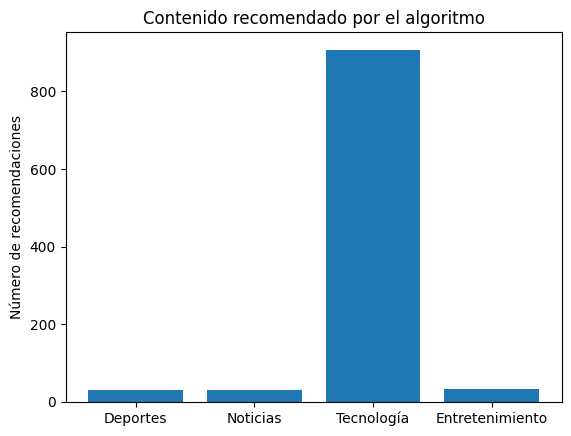

In [ ]:
counts = [actions.count(i) for i in range(n_actions)]

plt.bar(content, counts)
plt.ylabel("Número de recomendaciones")
plt.title("Contenido recomendado por el algoritmo")
plt.show()

Con ε = 0.1, el algoritmo exploró aproximadamente el 10% de las veces y utilizó el resto de las iteraciones para explotar la acción que consideraba mejor. Gracias a esta exploración, pudo probar las diferentes opciones y aprender que Tecnología tenía la mayor probabilidad de recompensa. Después de aprenderlo, comenzó a seleccionarla con mayor frecuencia. El desempeño fue considerablemente mejor que con ε = 0.

## Entorno estacionario
epsilon = 0.3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)

# Estimación inicial de recompensa
Q = np.zeros(n_actions)

# Número de veces que cada acción ha sido seleccionada
N = np.zeros(n_actions)

#cuánto explora el algortimo
eplison = 0.3
T = 1000

rewards = []
actions = []

for t in range(T):

    # Exploration
    if np.random.rand() < eplison:
        action = np.random.randint(n_actions)

    # Exploitation
    else:
        action = np.argmax(Q)

    # Respuesta del usuario
    reward = np.random.rand() < true_prob[action]

    # Guardamos resultados
    rewards.append(reward)
    actions.append(action)

    # Actualizamos la estimación
    N[action] += 1
    #promedio acumulado de las recompensas
    Q[action] += (reward - Q[action]) / N[action]


In [ ]:
for i in range(n_actions):
    print(
        content[i],
        " | valor real:", true_prob[i],
        " | valor aprendido:", round(Q[i], 3),
        " | veces mostrado:", int(N[i])
    )

Deportes  | valor real: 0.2  | valor aprendido: 0.227  | veces mostrado: 75
Noticias  | valor real: 0.6  | valor aprendido: 0.642  | veces mostrado: 81
Tecnología  | valor real: 0.8  | valor aprendido: 0.808  | veces mostrado: 771
Entretenimiento  | valor real: 0.4  | valor aprendido: 0.479  | veces mostrado: 73


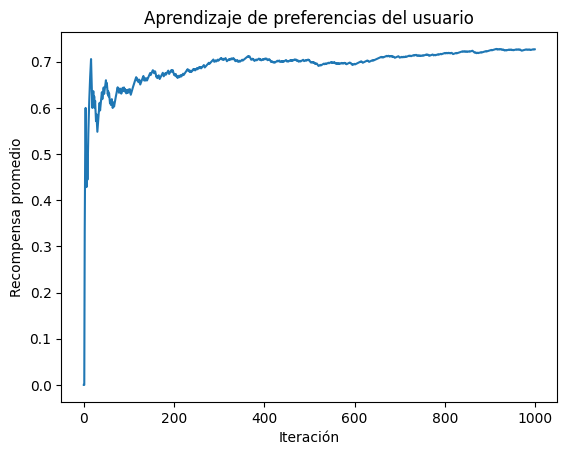

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Aprendizaje de preferencias del usuario")
plt.show()

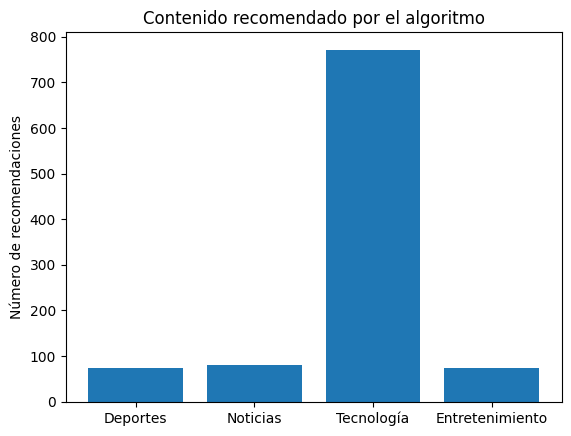

In [ ]:
counts = [actions.count(i) for i in range(n_actions)]

plt.bar(content, counts)
plt.ylabel("Número de recomendaciones")
plt.title("Contenido recomendado por el algoritmo")
plt.show()

Con ε = 0.3, el algoritmo realizó más exploración que con ε = 0.1. Esto permitió conocer las diferentes opciones y detectar que Tecnología era la mejor alternativa. Sin embargo, al explorar aproximadamente el 30% de las veces, también seleccionó con mayor frecuencia acciones que tenían una menor probabilidad de recompensa. Por lo tanto, aunque logró aprender la mejor opción, el exceso de exploración redujo un poco el desempeño.

##Entorno estacionario

epsilon = 0.5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)

# Estimación inicial de recompensa
Q = np.zeros(n_actions)

# Número de veces que cada acción ha sido seleccionada
N = np.zeros(n_actions)

#cuánto explora el algortimo
eplison = 0.5
T = 1000

rewards = []
actions = []

for t in range(T):

    # Exploration
    if np.random.rand() < eplison:
        action = np.random.randint(n_actions)

    # Exploitation
    else:
        action = np.argmax(Q)

    # Respuesta del usuario
    reward = np.random.rand() < true_prob[action]

    # Guardamos resultados
    rewards.append(reward)
    actions.append(action)

    # Actualizamos la estimación
    N[action] += 1
    #promedio acumulado de las recompensas
    Q[action] += (reward - Q[action]) / N[action]


In [ ]:
for i in range(n_actions):
    print(
        content[i],
        " | valor real:", true_prob[i],
        " | valor aprendido:", round(Q[i], 3),
        " | veces mostrado:", int(N[i])
    )

Deportes  | valor real: 0.2  | valor aprendido: 0.213  | veces mostrado: 150
Noticias  | valor real: 0.6  | valor aprendido: 0.577  | veces mostrado: 123
Tecnología  | valor real: 0.8  | valor aprendido: 0.816  | veces mostrado: 621
Entretenimiento  | valor real: 0.4  | valor aprendido: 0.406  | veces mostrado: 106


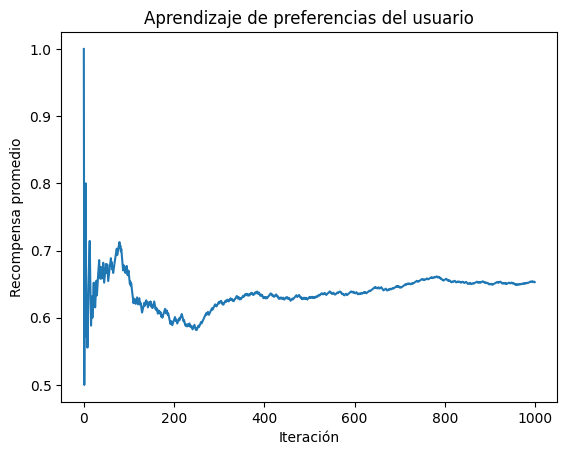

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Aprendizaje de preferencias del usuario")
plt.show()

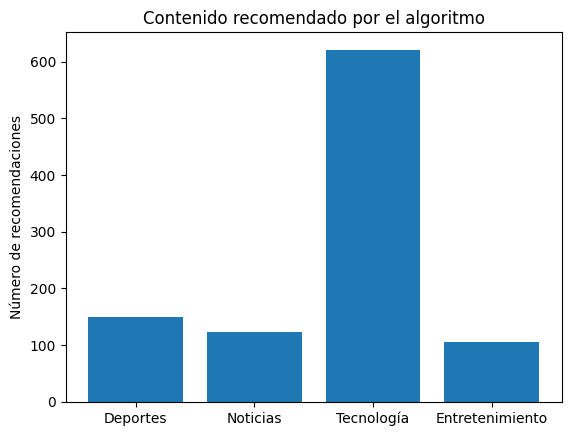

In [ ]:
counts = [actions.count(i) for i in range(n_actions)]

plt.bar(content, counts)
plt.ylabel("Número de recomendaciones")
plt.title("Contenido recomendado por el algoritmo")
plt.show()

Con ε = 0.5, el algoritmo exploró aproximadamente la mitad de las veces y explotó la acción considerada mejor en la otra mitad. Esto permitió que aprendiera rápidamente las recompensas de las diferentes opciones y reconociera que Tecnología era la mejor. Sin embargo, debido al alto nivel de exploración, continuó seleccionando otras opciones con frecuencia, por lo que obtuvo una recompensa promedio menor que con un valor intermedio de ε.

##Entorno estacionario
epsilon = 0.9
(explora el 90% de las veces y solo explota el 10%)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)

# Estimación inicial de recompensa
Q = np.zeros(n_actions)

# Número de veces que cada acción ha sido seleccionada
N = np.zeros(n_actions)

#cuánto explora el algortimo
eplison = 0.9
T = 1000

rewards = []
actions = []

for t in range(T):

    # Exploration
    if np.random.rand() < eplison:
        action = np.random.randint(n_actions)

    # Exploitation
    else:
        action = np.argmax(Q)

    # Respuesta del usuario
    reward = np.random.rand() < true_prob[action]

    # Guardamos resultados
    rewards.append(reward)
    actions.append(action)

    # Actualizamos la estimación
    N[action] += 1
    #promedio acumulado de las recompensas
    Q[action] += (reward - Q[action]) / N[action]


In [ ]:
for i in range(n_actions):
    print(
        content[i],
        " | valor real:", true_prob[i],
        " | valor aprendido:", round(Q[i], 3),
        " | veces mostrado:", int(N[i])
    )

Deportes  | valor real: 0.2  | valor aprendido: 0.224  | veces mostrado: 250
Noticias  | valor real: 0.6  | valor aprendido: 0.531  | veces mostrado: 211
Tecnología  | valor real: 0.8  | valor aprendido: 0.803  | veces mostrado: 315
Entretenimiento  | valor real: 0.4  | valor aprendido: 0.393  | veces mostrado: 224


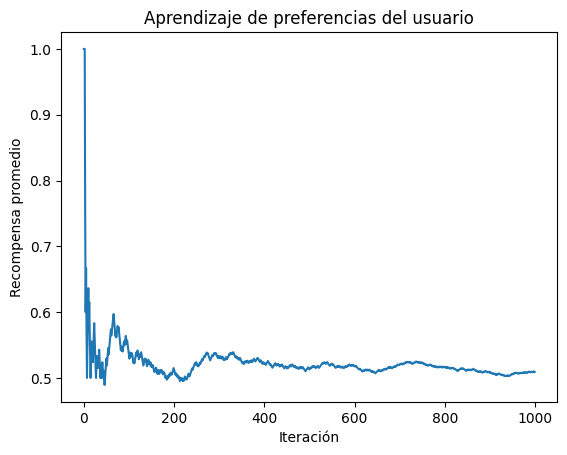

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Aprendizaje de preferencias del usuario")
plt.show()

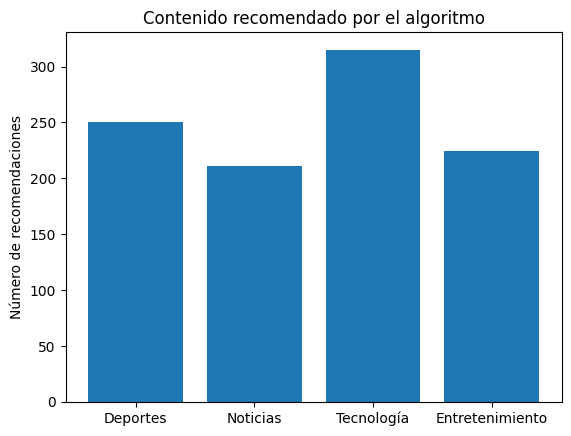

In [ ]:
counts = [actions.count(i) for i in range(n_actions)]

plt.bar(content, counts)
plt.ylabel("Número de recomendaciones")
plt.title("Contenido recomendado por el algoritmo")
plt.show()

Con ε = 0.9, el algoritmo explora el 90% de las veces y solo explota el 10%. Eso sirve para mostrar claramente que una exploración excesiva perjudica el rendimiento cuando el entorno no cambia.

Con ε = 0.9, el algoritmo exploró aproximadamente el 90% de las veces y solo explotó el 10%. Aunque pudo conocer las diferentes opciones, la gran cantidad de exploración provocó que seleccionara frecuentemente acciones con menor probabilidad de recompensa. Por esta razón, el algoritmo aprendió cuál era la mejor opción, pero no la aprovechó la mayor parte del tiempo. El desempeño fue menor debido al exceso de exploración.

Entorno estacionario

Experimento con diferentes valores de ε

In [ ]:
import pandas as pd

resultados = {
    "epsilon": [0.0, 0.1, 0.3, 0.5, 0.9],
    "Deportes": [1000, 30, 75, 150, 250],
    "Noticias": [0, 30, 81, 123, 211],
    "Tecnología": [0, 907, 771, 621, 315],
    "Entretenimiento": [0, 33, 73, 106, 224]
}

tabla = pd.DataFrame(resultados)

tabla

,epsilon,Deportes,Noticias,Tecnología,Entretenimiento
0,0.0,1000,0,0,0
1,0.1,30,30,907,33
2,0.3,75,81,771,73
3,0.5,150,123,621,106
4,0.9,250,211,315,224


Al aumentar ε, aumenta la exploración del algoritmo. Con ε = 0, el algoritmo no exploró y terminó seleccionando Deportes en las 1000 iteraciones. Al utilizar valores mayores de ε, el algoritmo comenzó a explorar las diferentes opciones y logró identificar Tecnología como la opción con mayor recompensa. Sin embargo, al aumentar demasiado ε, también aumentó la cantidad de recomendaciones de las otras opciones, reduciendo la explotación de la mejor alternativa

Conclusion para el entorno estacionario
En el entorno estacionario, se observa que un ε demasiado bajo puede impedir que el algoritmo descubra la mejor acción, mientras que un ε demasiado alto provoca demasiada exploración y reduce la recompensa obtenida. Un valor intermedio, como ε = 0.1 o ε = 0.3, permite encontrar un mejor equilibrio entre exploración y explotación.

##Entorno no-estacionario

Epsilon = 0.0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)

epsilon = 0.0
alpha = 0.1
T = 1000

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
best_prob_over_time = []

for t in range(T):

    # Preferencias reales del usuario cambian a mitad del experimento
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])

    best_prob_over_time.append(np.max(true_prob))

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)

    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0

    actions.append(action)
    rewards.append(reward)
    N[action] += 1

    # Actualización para caso no estacionario
    Q[action] = Q[action] + alpha * (reward - Q[action])

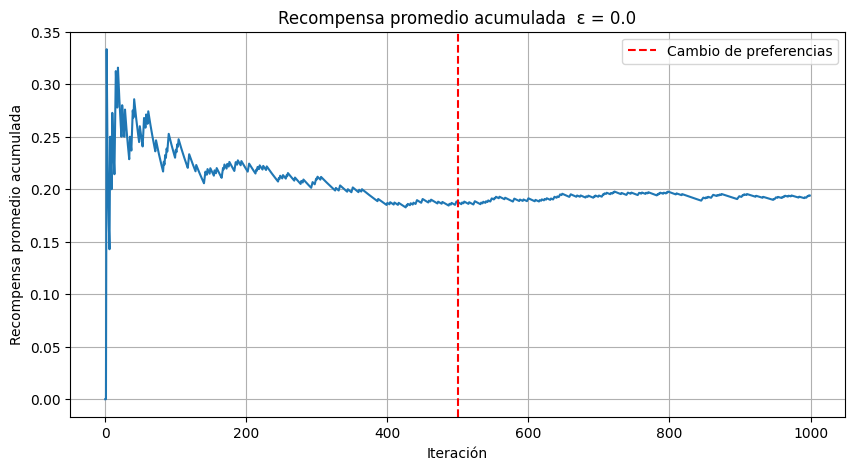

In [ ]:
#Este chunk utiliza las recompensas que se guardaron en el anterior
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.figure(figsize=(10, 5))

plt.plot(average_reward)

plt.axvline(
    500,
    color="red",
    linestyle="--",
    label="Cambio de preferencias"
)

plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title(f"Recompensa promedio acumulada  ε = {epsilon}")
plt.legend()
plt.grid()

plt.show()

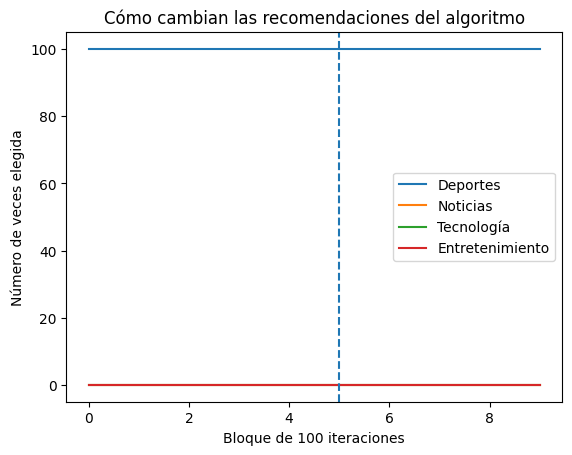

In [ ]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

epsilon = 0.01

Con ε = 0.01, prácticamente no hay exploración, por lo que puede tardar mucho en detectar el cambio

el usuario cambió de preferencias de tecnología a entretenimiento. el algoritmo tiene que darse cuenta y adaptarse

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)

epsilon = 0.01
alpha = 0.1
T = 1000

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
best_prob_over_time = []

for t in range(T):

    # Preferencias reales del usuario cambian a mitad del experimento
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])

    best_prob_over_time.append(np.max(true_prob))

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)

    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0

    actions.append(action)
    rewards.append(reward)
    N[action] += 1

    # Actualización para caso no estacionario
    Q[action] = Q[action] + alpha * (reward - Q[action])

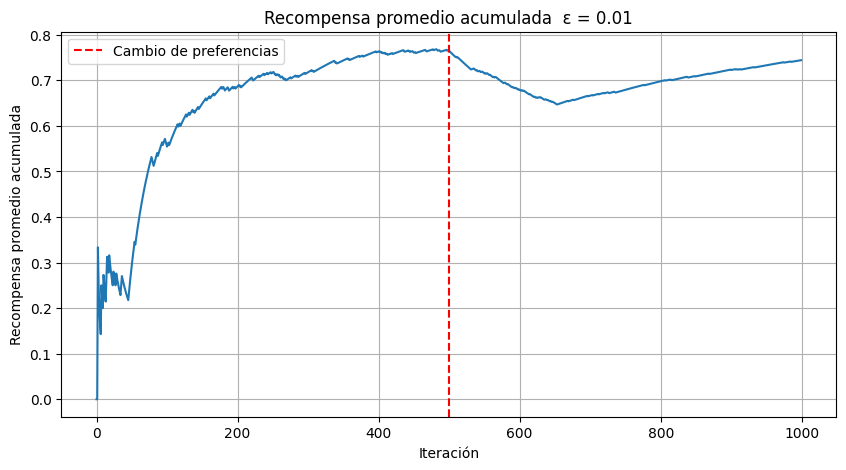

In [ ]:
#Este chunk utiliza las recompensas que se guardaron en el anterior
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.figure(figsize=(10, 5))

plt.plot(average_reward)

plt.axvline(
    500,
    color="red",
    linestyle="--",
    label="Cambio de preferencias"
)

plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title(f"Recompensa promedio acumulada  ε = {epsilon}")
plt.legend()
plt.grid()

plt.show()

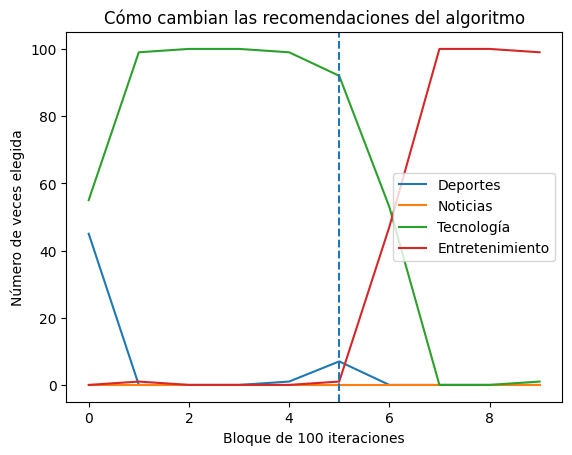

In [ ]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

Epsilon = 0.1

Con ε = 0.1, tiene cierta capacidad para descubrir que las preferencias cambiaron


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)

epsilon = 0.1
alpha = 0.1
T = 1000

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
best_prob_over_time = []

for t in range(T):

    # Preferencias reales del usuario cambian a mitad del experimento
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])

    best_prob_over_time.append(np.max(true_prob))

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)

    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0

    actions.append(action)
    rewards.append(reward)
    N[action] += 1

    # Actualización para caso no estacionario
    Q[action] = Q[action] + alpha * (reward - Q[action])

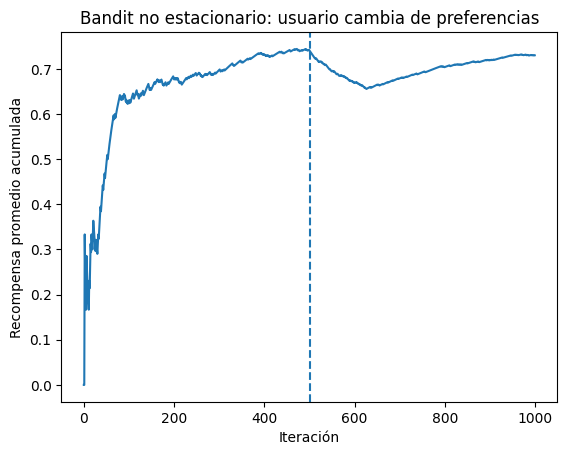

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.axvline(500, linestyle="--")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title("Bandit no estacionario: usuario cambia de preferencias")
plt.show()

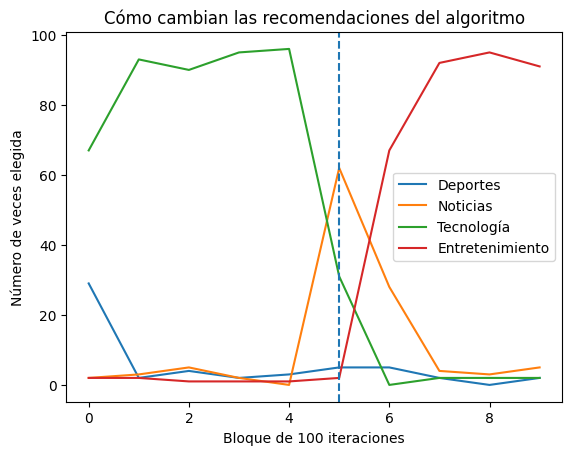

In [ ]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

Epsilon = 0.2

Con ε = 0.2, explora un poco más que cuando ε = 0.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)

epsilon = 0.2
alpha = 0.1
T = 1000

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
best_prob_over_time = []

for t in range(T):

    # Preferencias reales del usuario cambian a mitad del experimento
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])

    best_prob_over_time.append(np.max(true_prob))

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)

    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0

    actions.append(action)
    rewards.append(reward)
    N[action] += 1

    # Actualización para caso no estacionario
    Q[action] = Q[action] + alpha * (reward - Q[action])

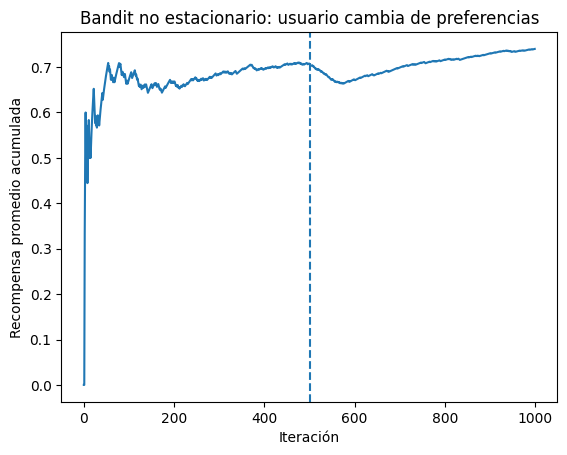

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.axvline(500, linestyle="--")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title("Bandit no estacionario: usuario cambia de preferencias")
plt.show()

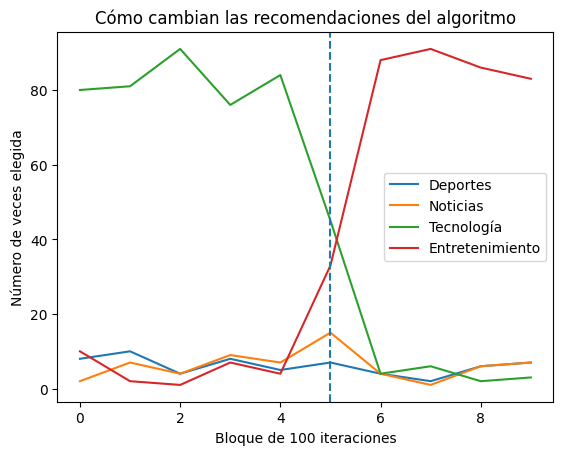

In [ ]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

Epsilon = 0.5

Con ε = 0.5, la mitad de las decisiones son exploratorias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)

epsilon = 0.5
alpha = 0.1
T = 1000

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
best_prob_over_time = []

for t in range(T):

    # Preferencias reales del usuario cambian a mitad del experimento
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])

    best_prob_over_time.append(np.max(true_prob))

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)

    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0

    actions.append(action)
    rewards.append(reward)
    N[action] += 1

    # Actualización para caso no estacionario
    Q[action] = Q[action] + alpha * (reward - Q[action])

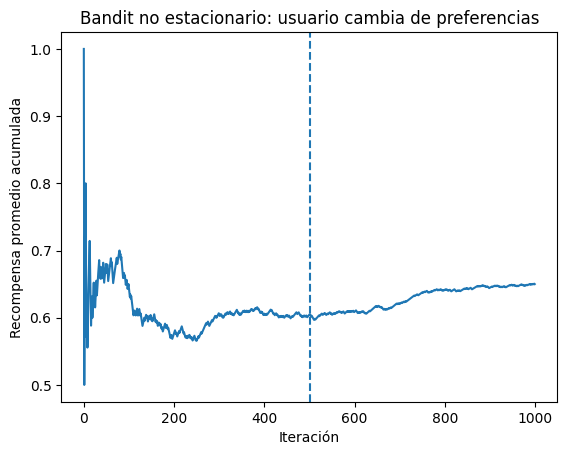

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.axvline(500, linestyle="--")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title("Bandit no estacionario: usuario cambia de preferencias")
plt.show()

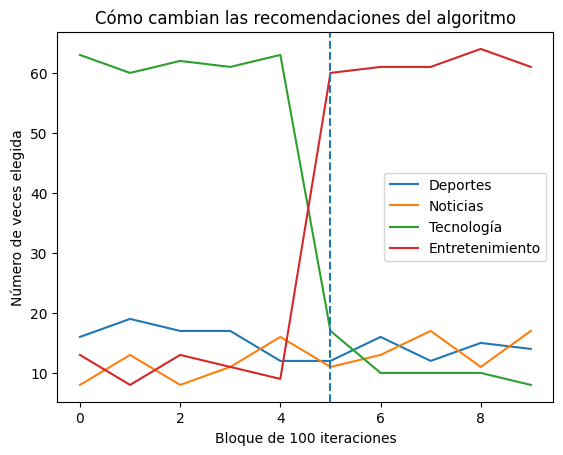

In [ ]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

Epsilon = 0.9

Con ε = 0.9, el algoritmo explora el 90% de las veces

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)

epsilon = 0.5
alpha = 0.1
T = 1000

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
best_prob_over_time = []

for t in range(T):

    # Preferencias reales del usuario cambian a mitad del experimento
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])

    best_prob_over_time.append(np.max(true_prob))

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)

    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0

    actions.append(action)
    rewards.append(reward)
    N[action] += 1

    # Actualización para caso no estacionario
    Q[action] = Q[action] + alpha * (reward - Q[action])

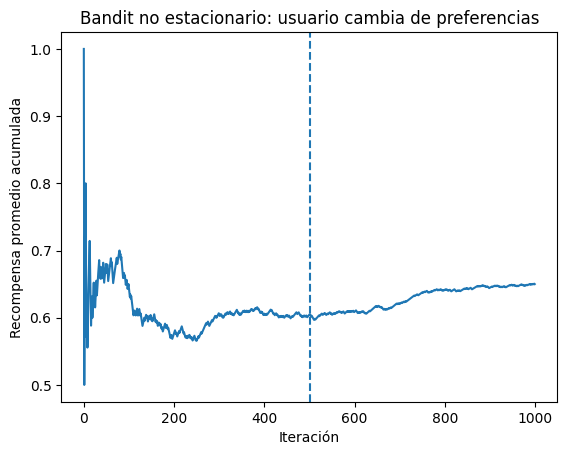

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.axvline(500, linestyle="--")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title("Bandit no estacionario: usuario cambia de preferencias")
plt.show()

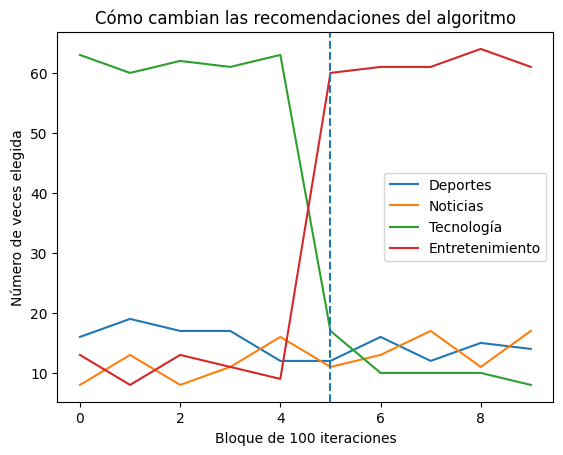

In [ ]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

2. Para el entorno estacionario usar tasa de aprendizaje constante y describir lo observado con el desempeño del algoritmo.

Para el entorno estacionario, el código NO está usando una tasa de aprendizaje constante se está usando: α = 1/N(a), conforme N aumenta, la tasa disminuye. Entonces debemos cambiar

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)

# Estimación inicial de recompensa
Q = np.zeros(n_actions)

# Número de veces que cada acción ha sido seleccionada
N = np.zeros(n_actions)

epsilon = 0.1
alpha = 0.1
T = 1000

rewards = []
actions = []

for t in range(T):

    # Exploration
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)

    # Exploitation
    else:
        action = np.argmax(Q)

    # Respuesta del usuario
    reward = np.random.rand() < true_prob[action]

    # Guardamos resultados
    rewards.append(reward)
    actions.append(action)

    # Actualizamos la estimación
    N[action] += 1
    Q[action] += alpha * (reward - Q[action])

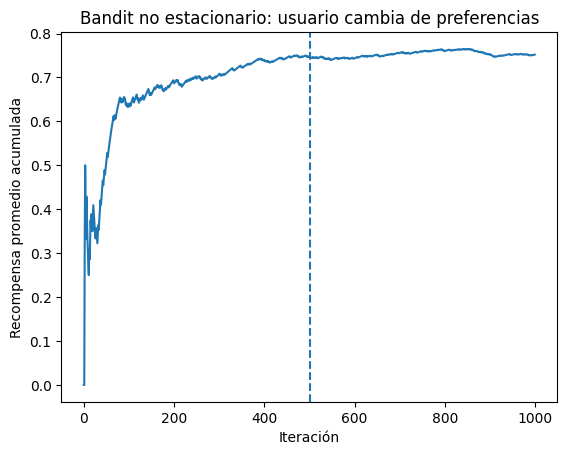

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.axvline(500, linestyle="--")
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title("Bandit no estacionario: usuario cambia de preferencias")
plt.show()

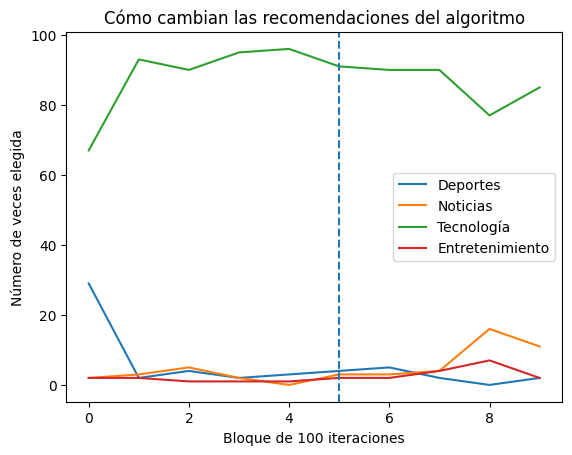

In [ ]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

Al utilizar una tasa de aprendizaje constante α = 0.1 en el entorno estacionario, el algoritmo continúa actualizando sus estimaciones de recompensa con el mismo peso en cada iteración. Como las preferencias del usuario no cambian, el algoritmo logra aprender progresivamente que Tecnología es la acción con mayor probabilidad de recompensa (0.8). La recompensa promedio aumenta inicialmente y posteriormente tiende a estabilizarse, mostrando que el algoritmo aprende a seleccionar la acción más beneficiosa.

3. Para el entorno no estacionario utilizar como tasa de aprendizaje       1/N(a)  y describir lo observado con el desempeño del algoritmo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)

epsilon = 0.1
T = 1000

Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
best_prob_over_time = []

for t in range(T):

    # Preferencias reales del usuario cambian a mitad del experimento
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])

    best_prob_over_time.append(np.max(true_prob))

    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)

    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0

    actions.append(action)
    rewards.append(reward)

    # Contamos cuántas veces se seleccionó la acción
    N[action] += 1

    # Tasa de aprendizaje = 1/N(a)
    alpha = 1 / N[action]

    # Actualización
    Q[action] = Q[action] + alpha * (reward - Q[action])

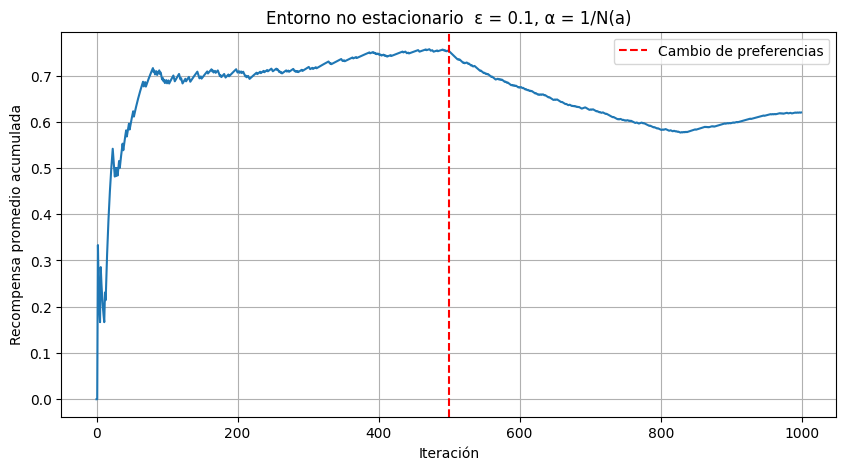

In [ ]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.figure(figsize=(10, 5))

plt.plot(average_reward)

plt.axvline(
    500,
    color="red",
    linestyle="--",
    label="Cambio de preferencias"
)

plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio acumulada")
plt.title(f"Entorno no estacionario  ε = {epsilon}, α = 1/N(a)")

plt.legend()
plt.grid()

plt.show()

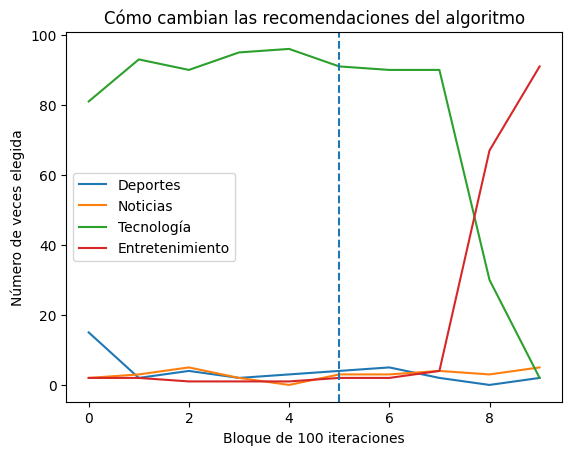

In [ ]:
window = 100
chosen_actions = []

for start in range(0, T, window):
    block = actions[start:start+window]
    counts = [block.count(a) for a in range(n_actions)]
    chosen_actions.append(counts)

chosen_actions = np.array(chosen_actions)

for a in range(n_actions):
    plt.plot(chosen_actions[:, a], label=content[a])

plt.axvline(5, linestyle="--")  # porque 500 = 5 bloques de 100
plt.xlabel("Bloque de 100 iteraciones")
plt.ylabel("Número de veces elegida")
plt.title("Cómo cambian las recomendaciones del algoritmo")
plt.legend()
plt.show()

En el entorno no estacionario, al utilizar una tasa de aprendizaje de α = 1/N(a), el algoritmo tiene dificultades para adaptarse al cambio de preferencias del usuario. Esto ocurre porque la tasa de aprendizaje disminuye a medida que aumenta el número de veces que se selecciona una acción. Por lo tanto, las nuevas recompensas tienen cada vez menor influencia sobre la estimación Q. Aunque antes del cambio el algoritmo aprende que Tecnología es la mejor opción, después de la iteración 500 puede tardar en reconocer que Entretenimiento se ha convertido en la mejor alternativa. Esto muestra que una tasa de aprendizaje decreciente puede ser adecuada para entornos estacionarios, pero presenta limitaciones en entornos donde las recompensas cambian con el tiempo.